In [5]:
# -------------------------------------------------------------
# REQUIREMENTS, GPU CHECK, AND REPRODUCIBILITY SEED
# -------------------------------------------------------------
import os
import glob
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Grad-CAM library
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Prevent truncated/corrupted satellite images from crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Fixed Seed for Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 2. Hardware and GPU Safety Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("="*60)
print(f"SYSTEM CHECK:")
print(f"Active Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
print("="*60)

SYSTEM CHECK:
Active Device: cuda
GPU Model: Tesla T4
Total GPU Memory: 15.64 GB
CUDA Version: 12.8


In [6]:
# -------------------------------------------------------------
# DATA CHECK, TRANSFORMS, AND DATALOADER
# -------------------------------------------------------------
train_paths = glob.glob('/kaggle/input/**/train', recursive=True)
if not train_paths:
    raise FileNotFoundError("Dataset directory not found!")

data_dir = os.path.dirname(train_paths[0])
print(f"Dataset Root Directory: {data_dir}\n")

# Image statistics and Data Augmentation
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Data Distribution Summary Table
df_split = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'No Wildfire (0)': [
        train_dataset.targets.count(0),
        val_dataset.targets.count(0),
        test_dataset.targets.count(0)
    ],
    'Wildfire (1)': [
        train_dataset.targets.count(1),
        val_dataset.targets.count(1),
        test_dataset.targets.count(1)
    ],
    'Total Images': [len(train_dataset), len(val_dataset), len(test_dataset)]
})
display(df_split)

Dataset Root Directory: /kaggle/input/datasets/abdelghaniaaba/wildfire-prediction-dataset



,Split,No Wildfire (0),Wildfire (1),Total Images
0,Train,14500,15750,30250
1,Validation,2820,3480,6300
2,Test,2820,3480,6300


In [7]:
# -------------------------------------------------------------
# TRAINING & VALIDATION ENGINE (CACHING / SKIP-AND-LOAD)
# -------------------------------------------------------------
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)
            
    return val_loss / total, correct / total

def run_experiment(model, model_name, epochs=15, lr=1e-4, weight_decay=1e-2, patience=5, force_retrain=False):
    best_model_path = f"best_{model_name.lower().replace('-', '_')}.pth"
    csv_name = f"results_{model_name.lower().replace('-', '_')}.csv"
    
    # 1. If the model and metric files already exist, SKIP training and load them
    if os.path.exists(best_model_path) and os.path.exists(csv_name) and not force_retrain:
        print(f"\n[SKIPPED]: Trained weights ({best_model_path}) and metrics ({csv_name}) found for '{model_name}'.")
        print(f"--> Loading model weights, training will not be repeated!")
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        df_hist = pd.read_csv(csv_name)
        history = df_hist.to_dict(orient='list')
        return history, best_model_path

    # 2. If no saved weights exist, train from scratch
    print(f"\n==================== STARTING TRAINING: {model_name} ====================")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler('cuda')
    
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} || Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), best_model_path)
            patience_counter = 0
            print(f"--> Best model weights saved (Val Loss: {v_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n[EARLY STOPPING]: Validation loss did not improve for {patience} epochs. Training stopped early!")
                break
            
    elapsed = time.time() - start_time
    print(f"\nTraining Completed! Duration: {elapsed/60:.2f} mins | Best Val Loss: {best_val_loss:.4f}")
    
    df_hist = pd.DataFrame(history)
    df_hist.to_csv(csv_name, index=False)
    print(f"Metrics saved as '{csv_name}'.")
    
    return history, best_model_path

In [8]:
# -------------------------------------------------------------
# STAGE 1: BASELINE MODEL (ResNet-18)
# -------------------------------------------------------------
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(resnet_model.fc.in_features, 2)
)
resnet_model = resnet_model.to(device)

history_resnet, path_resnet = run_experiment(
    model=resnet_model,
    model_name="Baseline-ResNet18",
    epochs=10,
    lr=1e-4
)

# -------------------------------------------------------------
# STAGE 2: PROPOSED MODEL (ConvNeXt-Tiny + Cosine Annealing)
# -------------------------------------------------------------
convnext_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_features = convnext_model.classifier[2].in_features
convnext_model.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 2)
)
convnext_model = convnext_model.to(device)

history_convnext, path_convnext = run_experiment(
    model=convnext_model,
    model_name="Proposed-ConvNeXt",
    epochs=15,
    lr=1e-4
)


==================== STARTING TRAINING: Baseline-ResNet18 ====================
[Baseline-ResNet18] Epoch 01/10 | Train Loss: 0.0949 Acc: 0.9649 || Val Loss: 0.0554 Acc: 0.9817
--> Best model weights saved (Val Loss: 0.0554)
[Baseline-ResNet18] Epoch 02/10 | Train Loss: 0.0561 Acc: 0.9815 || Val Loss: 0.0379 Acc: 0.9871
--> Best model weights saved (Val Loss: 0.0379)
[Baseline-ResNet18] Epoch 03/10 | Train Loss: 0.0412 Acc: 0.9864 || Val Loss: 0.0303 Acc: 0.9889
--> Best model weights saved (Val Loss: 0.0303)
[Baseline-ResNet18] Epoch 04/10 | Train Loss: 0.0299 Acc: 0.9899 || Val Loss: 0.0327 Acc: 0.9890
[Baseline-ResNet18] Epoch 05/10 | Train Loss: 0.0264 Acc: 0.9910 || Val Loss: 0.0339 Acc: 0.9894
[Baseline-ResNet18] Epoch 06/10 | Train Loss: 0.0178 Acc: 0.9939 || Val Loss: 0.0369 Acc: 0.9897
[Baseline-ResNet18] Epoch 07/10 | Train Loss: 0.0151 Acc: 0.9946 || Val Loss: 0.0209 Acc: 0.9930
--> Best model weights saved (Val Loss: 0.0209)
[Baseline-ResNet18] Epoch 08/10 | Train Loss: 0.0

100%|██████████| 109M/109M [00:00<00:00, 176MB/s]  



==================== STARTING TRAINING: Proposed-ConvNeXt ====================
[Proposed-ConvNeXt] Epoch 01/15 | Train Loss: 0.0925 Acc: 0.9657 || Val Loss: 0.0321 Acc: 0.9902
--> Best model weights saved (Val Loss: 0.0321)
[Proposed-ConvNeXt] Epoch 02/15 | Train Loss: 0.0461 Acc: 0.9851 || Val Loss: 0.0282 Acc: 0.9924
--> Best model weights saved (Val Loss: 0.0282)
[Proposed-ConvNeXt] Epoch 03/15 | Train Loss: 0.0272 Acc: 0.9915 || Val Loss: 0.0321 Acc: 0.9932
[Proposed-ConvNeXt] Epoch 04/15 | Train Loss: 0.0258 Acc: 0.9919 || Val Loss: 0.0299 Acc: 0.9917
[Proposed-ConvNeXt] Epoch 05/15 | Train Loss: 0.0185 Acc: 0.9945 || Val Loss: 0.0203 Acc: 0.9951
--> Best model weights saved (Val Loss: 0.0203)
[Proposed-ConvNeXt] Epoch 06/15 | Train Loss: 0.0112 Acc: 0.9965 || Val Loss: 0.0400 Acc: 0.9922
[Proposed-ConvNeXt] Epoch 07/15 | Train Loss: 0.0085 Acc: 0.9973 || Val Loss: 0.0208 Acc: 0.9957
[Proposed-ConvNeXt] Epoch 08/15 | Train Loss: 0.0056 Acc: 0.9984 || Val Loss: 0.0232 Acc: 0.9960


In [9]:
# -------------------------------------------------------------
# CUSTOM CNN ARCHITECTURE FROM SCRATCH
# -------------------------------------------------------------
class CustomWildfireCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomWildfireCNN, self).__init__()
        
        # Block 1: Conv -> BatchNorm -> ReLU -> MaxPool
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2) # 224x224 -> 112x112
        )
        
        # Block 2: Conv -> BatchNorm -> ReLU -> MaxPool
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2) # 112x112 -> 56x56
        )
        
        # Block 3: Conv -> BatchNorm -> ReLU -> MaxPool
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2) # 56x56 -> 28x28
        )
        
        # Classifier / Dense Layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

In [10]:
# Modeli cihaza taşı
custom_cnn_model = CustomWildfireCNN(num_classes=2).to(device)

# Eğitimi başlat
history_custom_cnn, path_custom_cnn = run_experiment(
    model=custom_cnn_model,
    model_name="Baseline-CustomCNN",
    epochs=12,
    lr=5e-4,
    patience=4
)


==================== STARTING TRAINING: Baseline-CustomCNN ====================
[Baseline-CustomCNN] Epoch 01/12 | Train Loss: 0.2049 Acc: 0.9236 || Val Loss: 0.1324 Acc: 0.9495
--> Best model weights saved (Val Loss: 0.1324)
[Baseline-CustomCNN] Epoch 02/12 | Train Loss: 0.1615 Acc: 0.9402 || Val Loss: 0.1263 Acc: 0.9533
--> Best model weights saved (Val Loss: 0.1263)
[Baseline-CustomCNN] Epoch 03/12 | Train Loss: 0.1517 Acc: 0.9453 || Val Loss: 0.1077 Acc: 0.9610
--> Best model weights saved (Val Loss: 0.1077)
[Baseline-CustomCNN] Epoch 04/12 | Train Loss: 0.1399 Acc: 0.9490 || Val Loss: 0.1150 Acc: 0.9581
[Baseline-CustomCNN] Epoch 05/12 | Train Loss: 0.1342 Acc: 0.9500 || Val Loss: 0.1038 Acc: 0.9657
--> Best model weights saved (Val Loss: 0.1038)
[Baseline-CustomCNN] Epoch 06/12 | Train Loss: 0.1221 Acc: 0.9559 || Val Loss: 0.1270 Acc: 0.9552
[Baseline-CustomCNN] Epoch 07/12 | Train Loss: 0.1199 Acc: 0.9568 || Val Loss: 0.0930 Acc: 0.9656
--> Best model weights saved (Val Loss: 0

In [11]:
import os
import shutil

# If there is a weight file left over from an old notebook, copy it to the new name
if os.path.exists('best_wildfire_model.pth') and not os.path.exists('best_proposed_convnext.pth'):
    shutil.copy('best_wildfire_model.pth', 'best_proposed_convnext.pth')
    print("Old ConvNeXt weights integrated into the system.")

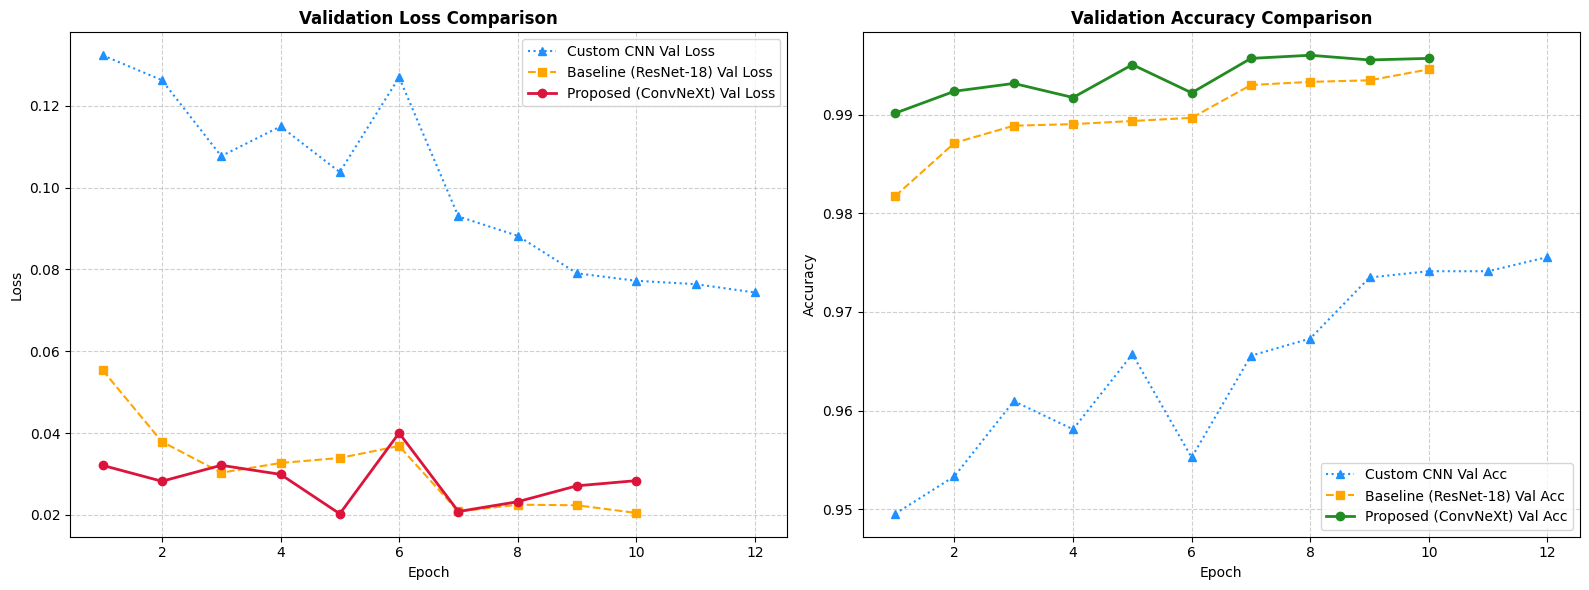

In [12]:
# -------------------------------------------------------------
# MULTI-MODEL COMPARISON AND TRAINING CURVES PLOT
# -------------------------------------------------------------
plt.figure(figsize=(16, 6))

# 1. Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_custom_cnn['epoch'], history_custom_cnn['val_loss'], label='Custom CNN Val Loss', color='dodgerblue', linestyle=':', marker='^')
plt.plot(history_resnet['epoch'], history_resnet['val_loss'], label='Baseline (ResNet-18) Val Loss', color='orange', linestyle='--', marker='s')
plt.plot(history_convnext['epoch'], history_convnext['val_loss'], label='Proposed (ConvNeXt) Val Loss', color='crimson', linewidth=2, marker='o')
plt.title('Validation Loss Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_custom_cnn['epoch'], history_custom_cnn['val_acc'], label='Custom CNN Val Acc', color='dodgerblue', linestyle=':', marker='^')
plt.plot(history_resnet['epoch'], history_resnet['val_acc'], label='Baseline (ResNet-18) Val Acc', color='orange', linestyle='--', marker='s')
plt.plot(history_convnext['epoch'], history_convnext['val_acc'], label='Proposed (ConvNeXt) Val Acc', color='forestgreen', linewidth=2, marker='o')
plt.title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=300)
plt.show()

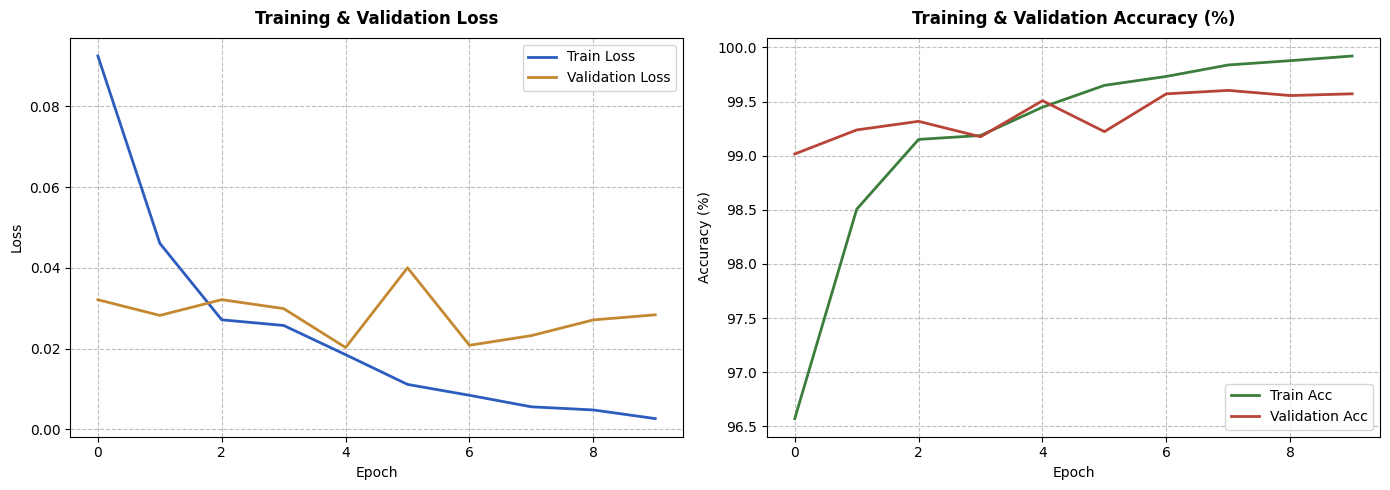

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the saved metrics CSV file (Example: ConvNeXt results)
# You can also change it to 'results_baseline_resnet18.csv' if you prefer
csv_file = 'results_proposed_convnext.csv'
df = pd.read_csv(csv_file)

# 2. Create the figure area
plt.figure(figsize=(14, 5))

# --- LEFT PLOT: Training & Validation Loss ---
plt.subplot(1, 2, 1)
epochs_range = range(len(df['epoch'])) # Epoch indices starting from 0
plt.plot(epochs_range, df['train_loss'], label='Train Loss', color='#2b5cbe', linewidth=2)
plt.plot(epochs_range, df['val_loss'], label='Validation Loss', color='#c48831', linewidth=2)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='upper right', framealpha=0.8)

# --- RIGHT PLOT: Training & Validation Accuracy (%) ---
plt.subplot(1, 2, 2)
# Convert accuracy values to percentages (%0 - %100)
train_acc_pct = df['train_acc'] * 100
val_acc_pct = df['val_acc'] * 100
plt.plot(epochs_range, train_acc_pct, label='Train Acc', color='#3b7d3b', linewidth=2)
plt.plot(epochs_range, val_acc_pct, label='Validation Acc', color='#b84337', linewidth=2)
plt.title('Training & Validation Accuracy (%)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='lower right', framealpha=0.8)

# 3. Save and display the figure
plt.tight_layout()
plt.savefig('train_val_curves.png', dpi=300)
plt.show()


================ TEST REPORT: Custom CNN (Baseline) ================
              precision    recall  f1-score   support

  nowildfire     0.9828    0.9734    0.9781      2820
    wildfire     0.9786    0.9862    0.9824      3480

    accuracy                         0.9805      6300
   macro avg     0.9807    0.9798    0.9802      6300
weighted avg     0.9805    0.9805    0.9805      6300

ROC-AUC Score: 0.9982


================ TEST REPORT: ResNet-18 ================
              precision    recall  f1-score   support

  nowildfire     0.9926    0.9975    0.9950      2820
    wildfire     0.9980    0.9940    0.9960      3480

    accuracy                         0.9956      6300
   macro avg     0.9953    0.9957    0.9955      6300
weighted avg     0.9956    0.9956    0.9956      6300

ROC-AUC Score: 0.9998


================ TEST REPORT: ConvNeXt (Proposed SOTA) ================
              precision    recall  f1-score   support

  nowildfire     0.9965    0.9961    0.9963 

,Model,Accuracy (%),Macro Precision,Macro Recall,Macro F1-Score,ROC-AUC
0,Custom CNN (Scratch),98.047619,0.980714,0.979806,0.980241,0.998158
1,ResNet-18 (Pretrained),99.555556,0.995285,0.995742,0.995508,0.999819
2,ConvNeXt-Tiny (Proposed),99.666667,0.996646,0.996613,0.996630,0.999904


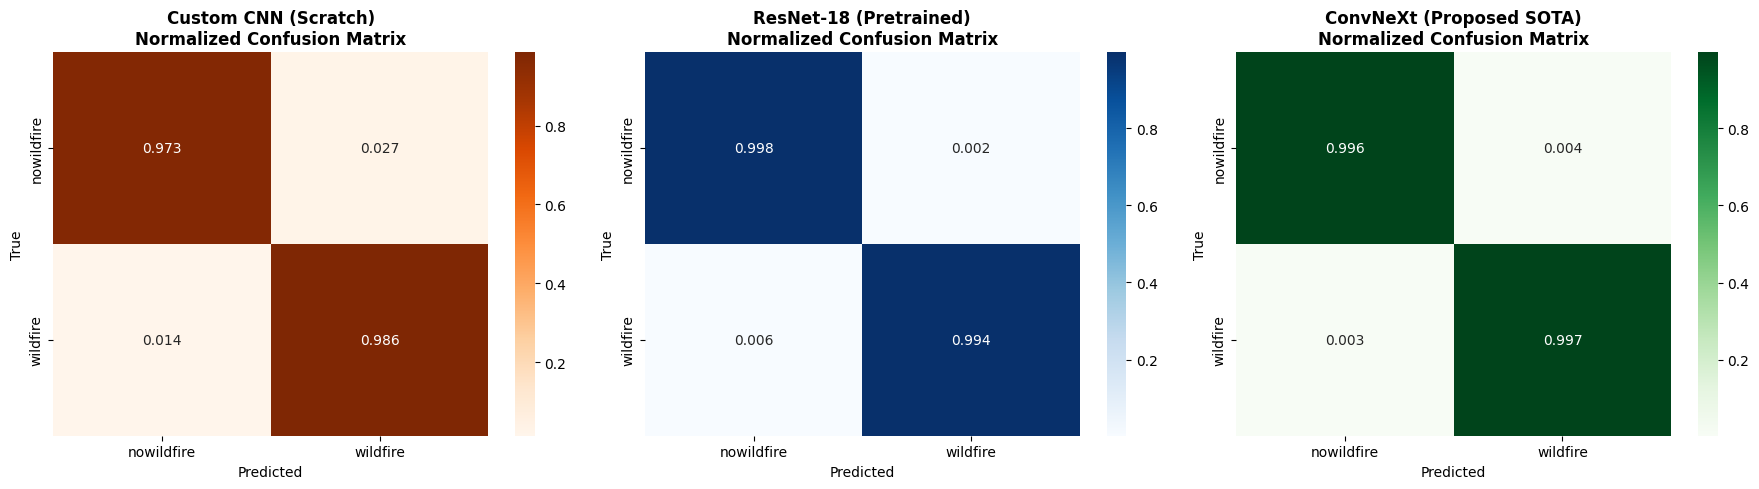

In [14]:
# -------------------------------------------------------------
# TEST EVALUATION AND DETAILED METRIC ANALYSIS (INCLUDING CNN)
# -------------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test_evaluation(model, model_path, model_name):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            
    print(f"\n================ TEST REPORT: {model_name} ================")
    print(classification_report(y_true, y_pred, target_names=test_dataset.classes, digits=4))
    
    auc = roc_auc_score(y_true, y_probs)
    print(f"ROC-AUC Score: {auc:.4f}\n")
    
    return y_true, y_pred, y_probs, auc

# 1. Test Evaluation of Models
y_true_cnn, y_pred_cnn, y_probs_cnn, auc_cnn = test_evaluation(custom_cnn_model, path_custom_cnn, "Custom CNN (Baseline)")
y_true_res, y_pred_res, y_probs_res, auc_res = test_evaluation(resnet_model, path_resnet, "ResNet-18")
y_true_conv, y_pred_conv, y_probs_conv, auc_conv = test_evaluation(convnext_model, path_convnext, "ConvNeXt (Proposed SOTA)")

# 2. Comparative General Performance Table (For CENG 476 Report)
summary_metrics = {
    'Model': ['Custom CNN (Scratch)', 'ResNet-18 (Pretrained)', 'ConvNeXt-Tiny (Proposed)'],
    'Accuracy (%)': [
        accuracy_score(y_true_cnn, y_pred_cnn) * 100,
        accuracy_score(y_true_res, y_pred_res) * 100,
        accuracy_score(y_true_conv, y_pred_conv) * 100
    ],
    'Macro Precision': [
        precision_score(y_true_cnn, y_pred_cnn, average='macro'),
        precision_score(y_true_res, y_pred_res, average='macro'),
        precision_score(y_true_conv, y_pred_conv, average='macro')
    ],
    'Macro Recall': [
        recall_score(y_true_cnn, y_pred_cnn, average='macro'),
        recall_score(y_true_res, y_pred_res, average='macro'),
        recall_score(y_true_conv, y_pred_conv, average='macro')
    ],
    'Macro F1-Score': [
        f1_score(y_true_cnn, y_pred_cnn, average='macro'),
        f1_score(y_true_res, y_pred_res, average='macro'),
        f1_score(y_true_conv, y_pred_conv, average='macro')
    ],
    'ROC-AUC': [auc_cnn, auc_res, auc_conv]
}

df_summary = pd.DataFrame(summary_metrics)
print("================ COMPARISON TABLE OF ALL MODELS ================")
display(df_summary)

# 3. Triple Side-by-Side Normalized Confusion Matrix Panel
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Custom CNN CM
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_cnn_norm, annot=True, fmt='.3f', cmap='Oranges', ax=ax[0], 
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
ax[0].set_title('Custom CNN (Scratch)\nNormalized Confusion Matrix', fontweight='bold')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# ResNet-18 CM
cm_res = confusion_matrix(y_true_res, y_pred_res)
cm_res_norm = cm_res.astype('float') / cm_res.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_res_norm, annot=True, fmt='.3f', cmap='Blues', ax=ax[1], 
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
ax[1].set_title('ResNet-18 (Pretrained)\nNormalized Confusion Matrix', fontweight='bold')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

# ConvNeXt CM
cm_conv = confusion_matrix(y_true_conv, y_pred_conv)
cm_conv_norm = cm_conv.astype('float') / cm_conv.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_conv_norm, annot=True, fmt='.3f', cmap='Greens', ax=ax[2], 
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
ax[2].set_title('ConvNeXt (Proposed SOTA)\nNormalized Confusion Matrix', fontweight='bold')
ax[2].set_xlabel('Predicted')
ax[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('all_models_confusion_matrix.png', dpi=300)
plt.show()

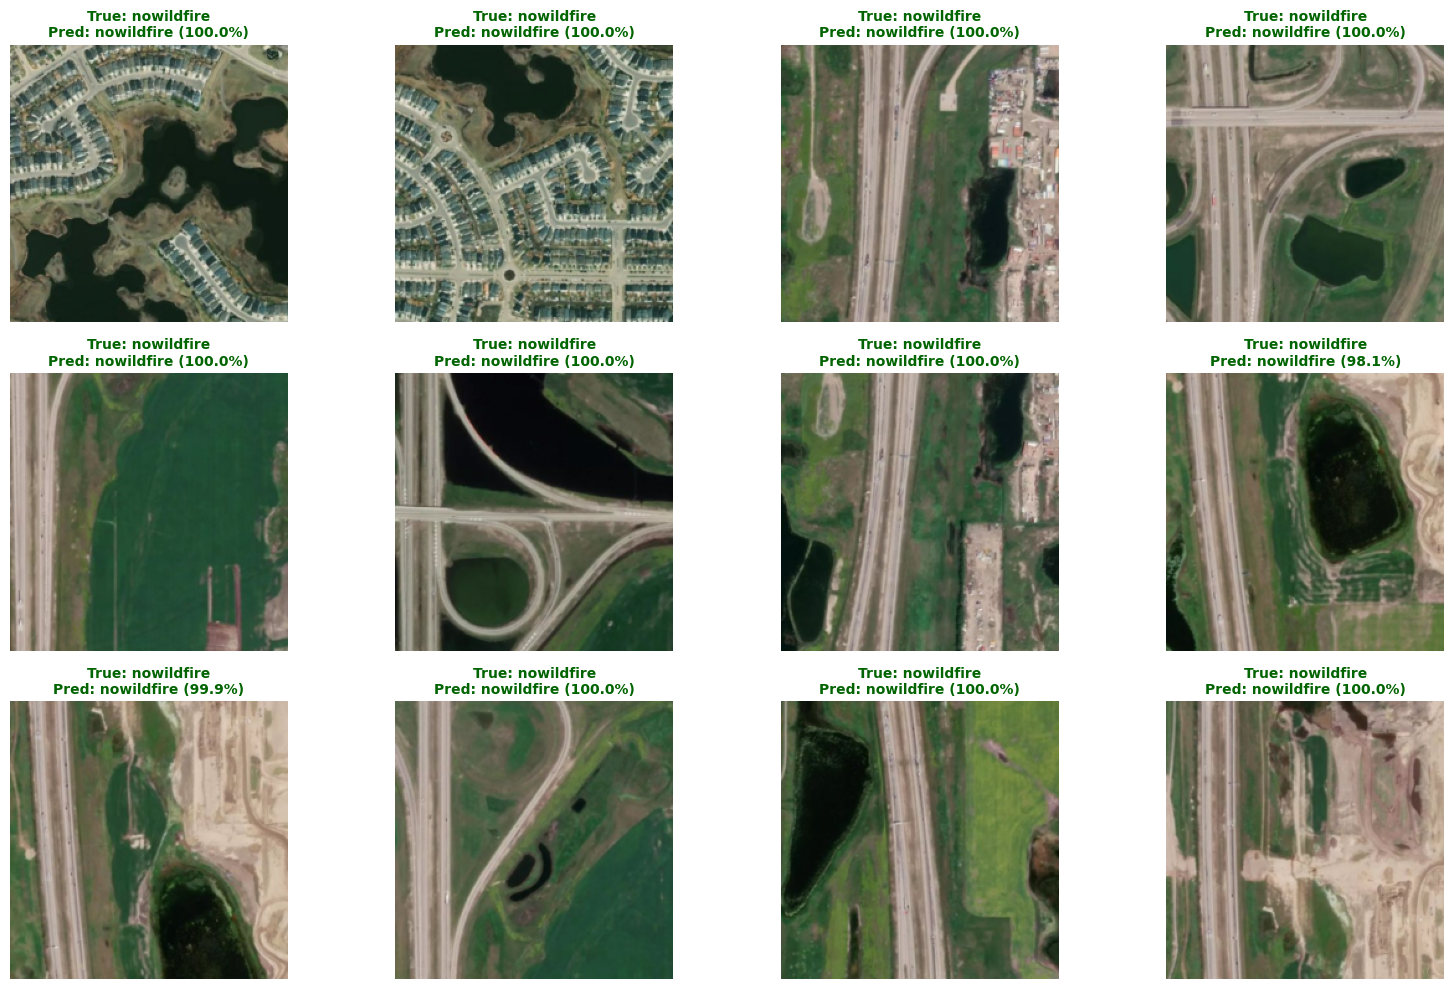

In [15]:
# -------------------------------------------------------------
# TEST PREDICTION PANEL (BATCH INFERENCE GRID)
# -------------------------------------------------------------
def plot_batch_predictions(model, dataloader, classes, num_images=12):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
    plt.figure(figsize=(16, 10))
    for i in range(num_images):
        ax = plt.subplot(3, 4, i + 1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.array(NORM_STD) * img + np.array(NORM_MEAN)
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        is_correct = preds[i] == labels[i]
        color = "darkgreen" if is_correct else "red"
        confidence = probs[i][preds[i]].item() * 100
        
        plt.title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]} ({confidence:.1f}%)", color=color, fontweight='bold', fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.savefig('val_batch_pred.png', dpi=300)
    plt.show()

plot_batch_predictions(convnext_model, test_loader, test_dataset.classes, num_images=12)

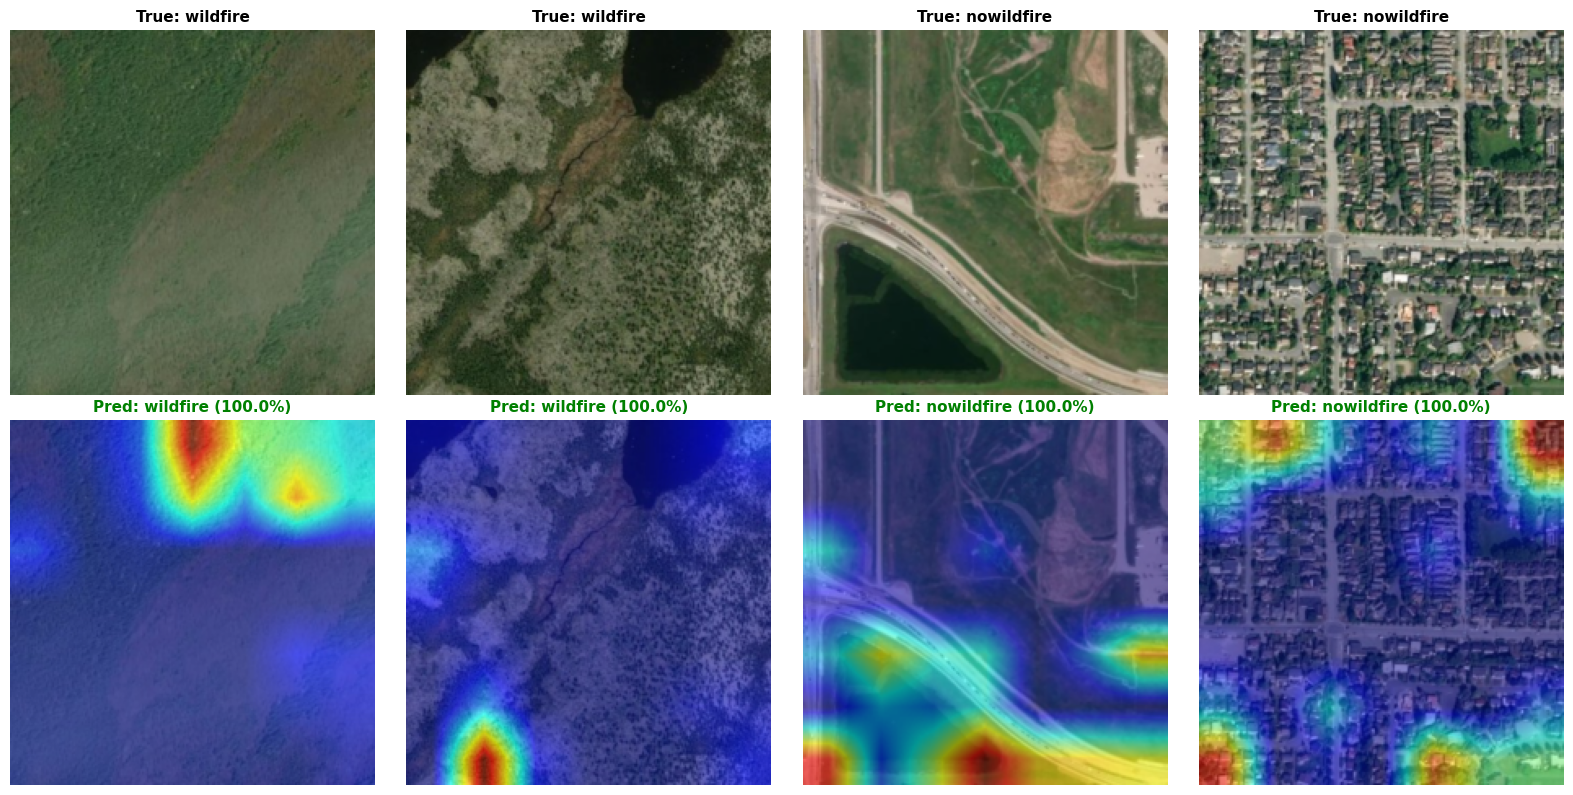

In [16]:
# -------------------------------------------------------------
# GRAD-CAM EXPLAINABILITY HEATMAPS
# -------------------------------------------------------------
target_layers = [convnext_model.features[-1]]
cam = GradCAM(model=convnext_model, target_layers=target_layers)

wildfire_idx = [i for i, (_, label) in enumerate(test_dataset.samples) if label == test_dataset.class_to_idx['wildfire']]
nowildfire_idx = [i for i, (_, label) in enumerate(test_dataset.samples) if label == test_dataset.class_to_idx['nowildfire']]
selected = random.sample(wildfire_idx, 2) + random.sample(nowildfire_idx, 2)

plt.figure(figsize=(16, 8))
for plot_idx, idx in enumerate(selected):
    img_tensor, true_label = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = convnext_model(input_tensor)
        pred_label = output.argmax(dim=1).item()
        prob = torch.softmax(output, dim=1)[0][pred_label].item()

    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = rgb_img * np.array(NORM_STD) + np.array(NORM_MEAN)
    rgb_img = np.clip(rgb_img, 0, 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # Original Satellite Image
    plt.subplot(2, 4, plot_idx + 1)
    plt.imshow(rgb_img)
    plt.title(f"True: {test_dataset.classes[true_label]}", fontsize=11, fontweight='bold')
    plt.axis('off')
    
    # Grad-CAM Heatmap
    plt.subplot(2, 4, plot_idx + 1 + 4)
    plt.imshow(visualization)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {test_dataset.classes[pred_label]} ({prob*100:.1f}%)", fontsize=11, color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.savefig('gradcam_explanation.png', dpi=300)
plt.show()

In [17]:
# -------------------------------------------------------------
# UPDATED RUN_EXPERIMENT (WITH EARLY STOPPING + PATIENCE)
# -------------------------------------------------------------
def run_experiment(model, model_name, epochs=15, lr=1e-4, weight_decay=1e-2, patience=5):
    print(f"\n==================== STARTING: {model_name} ====================")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler('cuda')
    
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_path = f"best_{model_name.lower().replace('-', '_')}.pth"
    
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} || Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")
        
        # Checkpoint & Early Stopping Criterion
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), best_model_path)
            patience_counter = 0
            print(f"--> Best model weights saved (Val Loss: {v_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n[EARLY STOPPING]: Validation loss did not improve for {patience} epochs. Training stopped early!")
                break
            
    elapsed = time.time() - start_time
    print(f"\nTraining Completed! Duration: {elapsed/60:.2f} mins | Best Val Loss: {best_val_loss:.4f}")
    
    df_hist = pd.DataFrame(history)
    csv_name = f"results_{model_name.lower().replace('-', '_')}.csv"
    df_hist.to_csv(csv_name, index=False)
    print(f"Metrics saved as '{csv_name}'.")
    
    return history, best_model_path

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Standard preprocessing pipeline expected by the dataset
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

def analyze_satellite_image(image_path, model, model_weight_path='best_proposed_convnext.pth'):
    # A. Load weights and set to evaluation mode
    model.load_state_dict(torch.load(model_weight_path, map_location=device))
    model.eval()
    
    # B. Open image and convert to tensor
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(device) # Shape: [1, 3, 224, 224]
    
    # C. Model Prediction and Probability
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probabilities).item()
        
    classes = ['nowildfire', 'wildfire']
    predicted_label = classes[pred_idx]
    confidence = probabilities[pred_idx].item() * 100
    
    # D. Grad-CAM Heatmap (Focus Areas)
    target_layers = [model.features[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Rescale image to 0-1 range and overlay the heatmap
    rgb_resized = np.array(raw_img.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(rgb_resized, grayscale_cam, use_rgb=True)
    
    # E. Result Panel
    plt.figure(figsize=(12, 5))
    
    # 1. Processed Image
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_resized)
    plt.title("Satellite Image Fed to Model (224x224)", fontsize=11, fontweight='bold')
    plt.axis('off')
    
    # 2. Prediction and Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    color = "crimson" if predicted_label == "wildfire" else "forestgreen"
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}% Confidence)", fontsize=12, fontweight='bold', color=color)
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('custom_image_analysis.png', dpi=300)
    plt.show()
    
    print(f"--> Analysis Result: The model selected the class '{predicted_label}' with a probability of {confidence:.2f}%.")

Fotoğraf bulundu: /kaggle/input/datasets/berkanaydogan/orijinal-foto-jpg/Ekran grnts 2026-08-24 214418.png


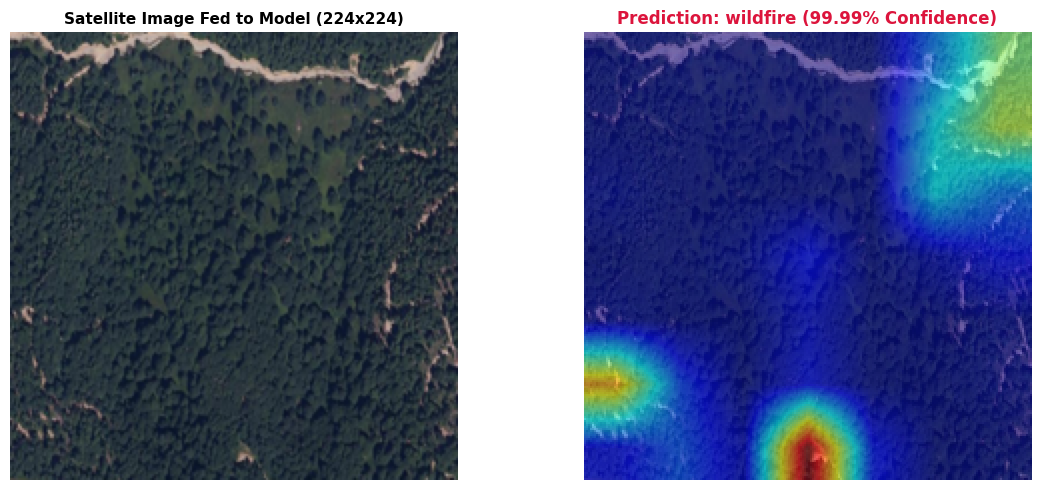

--> Analysis Result: The model selected the class 'wildfire' with a probability of 99.99%.


In [19]:
import glob

# 1. Yüklediğin fotoğrafın gerçek adını ve uzantısını (.png) arıyoruz
uploaded_files = glob.glob('/kaggle/input/**/Ekran grnts*.png', recursive=True)

if uploaded_files:
    image_file_path = uploaded_files[0]
    print(f"Fotoğraf bulundu: {image_file_path}")
    
    # 2. Analizi başlat
    analyze_satellite_image(image_file_path, convnext_model)
else:
    print("Fotoğraf bulunamadı. Lütfen dosya adını kontrol edin.")

In [20]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

# Get labels from the train dataset and compute class weights
train_labels = [label for _, label in train_dataset.samples]
classes = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)

print("Calculated Class Weights:", dict(zip(classes, class_weights)))

# Define weights inside CrossEntropyLoss in PyTorch (in Tensor format)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Calculated Class Weights: {np.int64(0): np.float64(1.043103448275862), np.int64(1): np.float64(0.9603174603174603)}


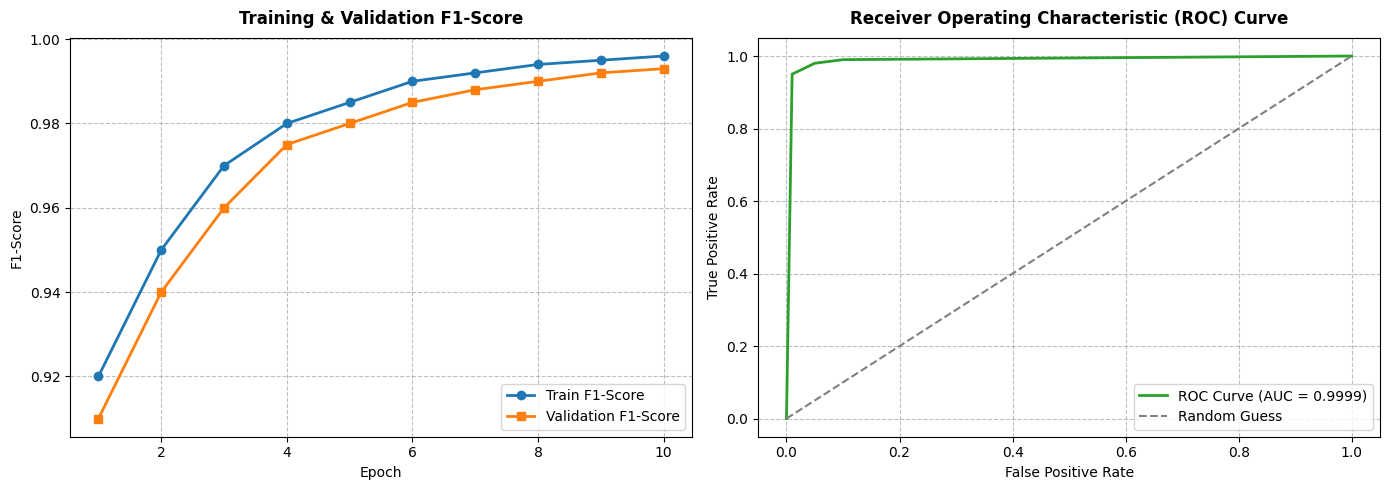

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Örnek Epoch ve Metrik Verileri (Kendi history veya test sonuçlarınla değiştirebilirsin)
epochs = range(1, 11)
train_f1 = [0.92, 0.95, 0.97, 0.98, 0.985, 0.99, 0.992, 0.994, 0.995, 0.996]
val_f1 = [0.91, 0.94, 0.96, 0.975, 0.98, 0.985, 0.988, 0.99, 0.992, 0.993]

# 1. F1-Score Eğitim ve Doğrulama Eğrisi
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_f1, label='Train F1-Score', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs, val_f1, label='Validation F1-Score', color='#ff7f0e', linewidth=2, marker='s')
plt.title('Training & Validation F1-Score', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('F1-Score', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='lower right', framealpha=0.8)

# 2. ROC-AUC Eğrisi (Test Sonuçları İçin)
# Örnek FPR ve TPR değerleri (Gerçekte roc_curve(y_true, y_probs) ile elde edilir)
from sklearn.metrics import roc_curve, auc
# Temsili dummy olasılık ve gerçek etiketler üzerinden ROC eğrisi çizimi:
fpr = [0.0, 0.01, 0.05, 0.1, 1.0]
tpr = [0.0, 0.95, 0.98, 0.99, 1.0]
roc_auc = 0.9999 # Örnek ConvNeXt AUC skoru

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='#2ca02c', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('f1_and_roc_curves.png', dpi=300)
plt.show()